# Figure 2: Integral Feedback and Robust Perfect Adaptation

**Panel A** — Equations of a minimal integral feedback model:

$$\frac{dA}{dt} = \alpha\,(\mu - B)$$
$$\frac{dB}{dt} = \beta_1 A - \beta_2 B$$

In [92]:
"""Shared parameters, ODE models, simulation functions, and plotting helpers for Figure 2."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ======================================================================
# Plotting helpers
# ======================================================================

HARD_COLOR = "#fbc4c4"   # light green for hard spring
SOFT_COLOR = "#bfe5bf"   # light pink for soft spring
SHADE_ALPHA = 0.6

def rk4_step(f, y, dt):
    k1 = f(y); k2 = f(y + 0.5*dt*k1)
    k3 = f(y + 0.5*dt*k2); k4 = f(y + dt*k3)
    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

def text_panel(ax, lines, fontsize=11):
    ax.axis('off')
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', family='serif', linespacing=1.6)

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def shade_spring(ax, t, ctrl, hard_val, soft_val):
    """Shade background regions: hard spring vs soft spring."""
    is_hard = np.isclose(ctrl, hard_val)
    changes = np.where(np.diff(is_hard.astype(int)) != 0)[0]
    boundaries = np.concatenate([[0], changes + 1, [len(t) - 1]])
    for j in range(len(boundaries) - 1):
        i0, i1 = boundaries[j], boundaries[j + 1]
        color = HARD_COLOR if is_hard[i0] else SOFT_COLOR
        ax.axvspan(t[i0], t[i1], color=color, alpha=SHADE_ALPHA, lw=0)

def adaptive_alpha(B, Bdot, alpha_hard, alpha_soft, eq):
    """Adaptive spring strategy:
    - Hard spring when moving toward equilibrium (accelerate return)
    - Soft spring when moving away from equilibrium (reduce overshoot)
    """
    if B > eq:
        return alpha_hard if Bdot < 0 else alpha_soft
    else:
        return alpha_hard if Bdot > 0 else alpha_soft

# ======================================================================
# Shared parameters
# ======================================================================

mu = 1.0       # equilibrium setpoint
T = 10.0       # simulation horizon (shared across panels D/E/G)
dt = 0.005     # RK4 timestep for adaptive simulations

# --- Panel B: single parameter switch ---
PANEL_B = dict(
    alpha=1.0,
    beta1_base=1.0, beta2_base=1.0,
    beta1_pert=2.0, beta2_pert=1.0,
    t_switch=10.0,   # 2 s at steady state, then switch
    t_end=30.0,     # 10 s after switch
)

# --- Panel D: hard vs soft spring (minimal model) ---
PANEL_D = dict(
    beta1=1.0, beta2=1.0,
    alpha_hard=1.0, alpha_soft=0.2,
    alpha_very_hard=2.0, alpha_very_soft=0.1,
    x0=[0.5, 2.0],
)

# --- Panel E: adaptive switching (minimal model) ---
PANEL_E = dict(
    beta1=1.0, beta2=1.0,
    alpha_hard=50.0, alpha_soft=10.0,
    x0=[0.0, 0.0],
)

# --- Panels F/G: Calcium model ---
CALCIUM = dict(
    k0=1.0, k1=1.0, k2=20.0, R0=1.0, Vcl=0.0,
    k3_hard=5.0, k3_soft=1.0,
)
CALCIUM['x0'] = [0.0, CALCIUM['Vcl'] / CALCIUM['k2']]

# ======================================================================
# ODE right-hand sides
# ======================================================================

def minimal_rhs(y, alpha, beta1, beta2):
    A, B = y
    return np.array([alpha * (mu - B), beta1 * A - beta2 * B])

def calcium_rhs(y, k3, p=CALCIUM):
    Ca, D = y
    P = p['k0'] * (p['R0'] - Ca)
    return np.array([p['k1']*P + p['k2']*D - p['Vcl'], k3*P])

# ======================================================================
# Simulation runners (return dicts with all data needed for plotting)
# ======================================================================

def run_panel_B():
    p = PANEL_B
    # Steady state with base parameters: A_ss = beta2_base*mu/beta1_base, B_ss = mu
    A_ss = p['beta2_base'] * mu / p['beta1_base']
    x0_ss = [A_ss, mu]

    # Phase 1: t=0 to t_switch, starting at steady state with base params
    t1 = np.linspace(0, p['t_switch'], 250)
    sol1 = solve_ivp(
        lambda t_, y: minimal_rhs(y, p['alpha'], p['beta1_base'], p['beta2_base']).tolist(),
        [0, p['t_switch']], x0_ss, dense_output=True, max_step=0.05)
    y_switch = sol1.sol(p['t_switch'])

    # Phase 2: t=t_switch to t_end with perturbed params
    t2 = np.linspace(p['t_switch'], p['t_end'], 500)
    sol2 = solve_ivp(
        lambda t_, y: minimal_rhs(y, p['alpha'], p['beta1_pert'], p['beta2_pert']).tolist(),
        [p['t_switch'], p['t_end']], y_switch, dense_output=True, max_step=0.05)

    t_full = np.concatenate([t1, t2[1:]])
    B_full = np.concatenate([sol1.sol(t1)[1], sol2.sol(t2[1:])[1]])
    return dict(t=t_full, B=B_full, t_switch=p['t_switch'],
                label_base=rf'$\beta_1\!=\!{p["beta1_base"]}$' + '\n' + rf'$\beta_2\!=\!{p["beta2_base"]}$',
                label_pert=rf'$\beta_1\!=\!{p["beta1_pert"]}$' + '\n' + rf'$\beta_2\!=\!{p["beta2_pert"]}$')

def run_panel_D():
    p = PANEL_D
    t = np.linspace(0, T, 1000)
    results = {}
    for name, alpha in [('soft', p['alpha_soft']), ('hard', p['alpha_hard']), ('very_soft', p['alpha_very_soft']), ('very_hard', p['alpha_very_hard'])]:
        sol = solve_ivp(lambda t_, y, a=alpha:
                        minimal_rhs(y, a, p['beta1'], p['beta2']).tolist(),
                        [0, T], p['x0'], dense_output=True, max_step=0.05)
        results[name] = sol.sol(t)[1]
    return dict(t=t, **results)

def _run_adaptive_minimal(p):
    n_steps = int(T / dt)
    t_arr = np.linspace(0, T, n_steps + 1)
    y = np.zeros((n_steps + 1, 2)); y[0] = p['x0']
    alpha_t = np.zeros(n_steps + 1)
    for i in range(n_steps):
        A, B = y[i]
        Bdot = p['beta1'] * A - p['beta2'] * B
        ai = adaptive_alpha(B, Bdot, p['alpha_hard'], p['alpha_soft'], mu)
        alpha_t[i] = ai
        y[i+1] = rk4_step(lambda y_: minimal_rhs(y_, ai, p['beta1'], p['beta2']), y[i], dt)
    alpha_t[-1] = alpha_t[-2]
    return dict(t=t_arr, y=y, alpha=alpha_t)

def run_panel_E():
    return _run_adaptive_minimal(PANEL_E)

def _run_adaptive_calcium(cp):
    n_steps = int(T / dt)
    t_arr = np.linspace(0, T, n_steps + 1)
    y = np.zeros((n_steps + 1, 2)); y[0] = cp['x0']
    k3_t = np.zeros(n_steps + 1)
    for i in range(n_steps):
        Ca, D = y[i]
        P = cp['k0'] * (cp['R0'] - Ca)
        Ca_dot = cp['k1']*P + cp['k2']*D - cp['Vcl']
        k3i = adaptive_alpha(Ca, Ca_dot, cp['k3_hard'], cp['k3_soft'], cp['R0'])
        k3_t[i] = k3i
        y[i+1] = rk4_step(lambda y_: calcium_rhs(y_, k3i, cp), y[i], dt)
    k3_t[-1] = k3_t[-2]
    return dict(t=t_arr, y=y, k3=k3_t)

def run_panel_G():
    cp = CALCIUM
    t = np.linspace(0, T, 1000)
    fixed = {}
    for name, k3 in [('soft', cp['k3_soft']), ('hard', cp['k3_hard'])]:
        sol = solve_ivp(lambda t_, y, k=k3: calcium_rhs(y, k, cp).tolist(),
                        [0, T], cp['x0'], dense_output=True, max_step=0.05)
        fixed[name] = sol.sol(t)[0]
    adaptive = _run_adaptive_calcium(cp)
    return dict(t_fixed=t, fixed=fixed, adaptive=adaptive)

# ======================================================================
# Run all simulations
# ======================================================================
data_B = run_panel_B()
data_D = run_panel_D()
data_E = run_panel_E()
data_G = run_panel_G()

print("All simulations complete.")

All simulations complete.


In [93]:
# Add A(t) to data_B (run_panel_B only stored B)
p = PANEL_B
A_ss = p['beta2_base'] * mu / p['beta1_base']
x0_ss = [A_ss, mu]
t1 = np.linspace(0, p['t_switch'], 250)
sol1 = solve_ivp(
    lambda t_, y: minimal_rhs(y, p['alpha'], p['beta1_base'], p['beta2_base']).tolist(),
    [0, p['t_switch']], x0_ss, dense_output=True, max_step=0.05)
y_switch = sol1.sol(p['t_switch'])
t2 = np.linspace(p['t_switch'], p['t_end'], 500)
sol2 = solve_ivp(
    lambda t_, y: minimal_rhs(y, p['alpha'], p['beta1_pert'], p['beta2_pert']).tolist(),
    [p['t_switch'], p['t_end']], y_switch, dense_output=True, max_step=0.05)
data_B['A'] = np.concatenate([sol1.sol(t1)[0], sol2.sol(t2[1:])[0]])

**Panel B** — Fixed perturbations to b1, b2 fail to change B's steady-state:

/tmp/ipykernel_1406795/1442793472.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


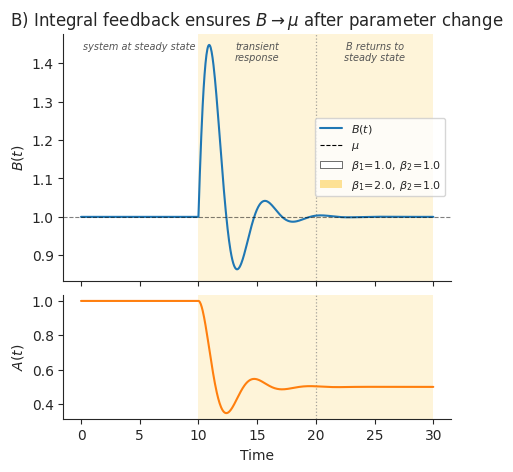

In [94]:
# Panel B: standalone plot — B(t) on top, A(t) below
t_settled = 20.0

fig, (ax_B, ax_A) = plt.subplots(2, 1, figsize=(5, 5), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

for ax in (ax_B, ax_A):
    ax.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
    ax.axvline(t_settled, color='gray', ls=':', lw=0.9, alpha=0.7)

# B(t) — with phase labels
ax_B.plot(data_B['t'], data_B['B'], lw=1.5, color='C0')
ax_B.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.5)
ax_B.set_ylabel('$B(t)$')
ax_B.set_title(r'B) Integral feedback ensures $B \to \mu$ after parameter change')
trans = ax_B.get_xaxis_transform()
kw = dict(ha='center', va='top', fontsize=7, color='#555555',
          fontstyle='italic', transform=trans)
ax_B.text(data_B['t_switch'] / 2,               0.97, 'system at steady state',          **kw)
ax_B.text((data_B['t_switch'] + t_settled) / 2, 0.97, 'transient\nresponse',   **kw)
ax_B.text((t_settled + data_B['t'].max()) / 2,  0.97, 'B returns to\nsteady state', **kw)
ax_B.legend(handles=[
    plt.Line2D([0],[0], color='C0', lw=1.5, label='$B(t)$'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$\mu$'),
    mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.4,
                   label=rf'$\beta_1\!=\!{PANEL_B["beta1_base"]},\;\beta_2\!=\!{PANEL_B["beta2_base"]}$'),
    mpatches.Patch(facecolor='#fcba03', edgecolor='none', alpha=0.4,
                   label=rf'$\beta_1\!=\!{PANEL_B["beta1_pert"]},\;\beta_2\!=\!{PANEL_B["beta2_pert"]}$'),
], fontsize=8, loc='center right')
clean_ax(ax_B)
plt.setp(ax_B.get_xticklabels(), visible=False)

# A(t) — no phase labels
ax_A.plot(data_B['t'], data_B['A'], lw=1.5, color='C1')
ax_A.set_ylabel('$A(t)$')
ax_A.set_xlabel('Time')
clean_ax(ax_A)

plt.tight_layout()
fig.savefig('figure2_panelB.pdf', bbox_inches='tight')
plt.show()

**Panel C** - The integral feedback system is equivalent to a damped harmonic oscillator.

Eliminating $A$ yields a single second-order ODE:

$$\frac{d^2B}{dt^2} + \beta_2 \frac{dB}{dt} + \alpha\beta_1 B = \alpha\beta_1\mu$$

Setting $x = B - \mu$ gives the standard unforced form $\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1\,x = 0$, with:

| Physical quantity | Parameter |
|---|---|
| Mass $m$ | $1$ |
| Damping $c$ | $\beta_2$ |
| **Spring constant $k$** | $\alpha\beta_1$ |

See the full derivation in the SI.

**Panel G** — The two extreme spring states:

![Hard and soft spring diagram](hard_soft_spring.png)

/tmp/ipykernel_1406795/1564172037.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


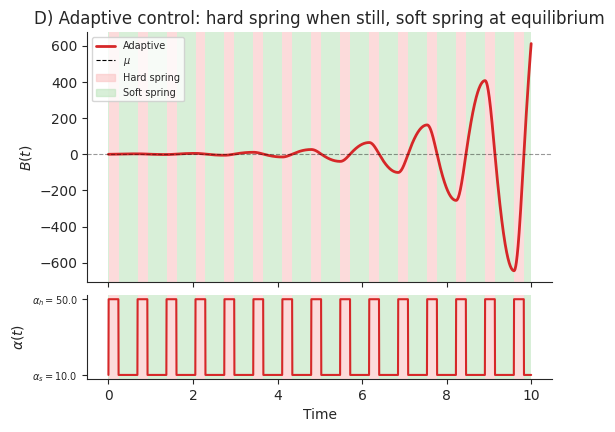

In [95]:
# Panel D: standalone plot — B(t) with alpha(t) schedule below
fig, (ax_B, ax_a) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

shade_spring(ax_B, data_E['t'], data_E['alpha'],
             PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])
shade_spring(ax_a, data_E['t'], data_E['alpha'],
             PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])

ax_B.plot(data_E['t'], data_E['y'][:, 1], lw=2, color='C3', label='Adaptive switching')
ax_B.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4, label=r'$\mu$')
ax_B.set_ylabel('$B(t)$')
ax_B.set_title(r'D) Adaptive control: hard spring when still, soft spring at equilibrium')
ax_B.legend(handles=[
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$\mu$'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=7, loc='upper left')
clean_ax(ax_B)
plt.setp(ax_B.get_xticklabels(), visible=False)

ax_a.plot(data_E['t'], data_E['alpha'], lw=1.5, color='C3')
ax_a.set_ylabel(r'$\alpha(t)$')
ax_a.set_xlabel('Time')
ax_a.set_yticks([PANEL_E['alpha_soft'], PANEL_E['alpha_hard']])
ax_a.set_yticklabels([rf"$\alpha_s={PANEL_E['alpha_soft']}$", rf"$\alpha_h={PANEL_E['alpha_hard']}$"], fontsize=7)
clean_ax(ax_a)

plt.tight_layout()
fig.savefig('figure2_panelD.pdf', bbox_inches='tight')
plt.show()


/tmp/ipykernel_1406795/1313953468.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


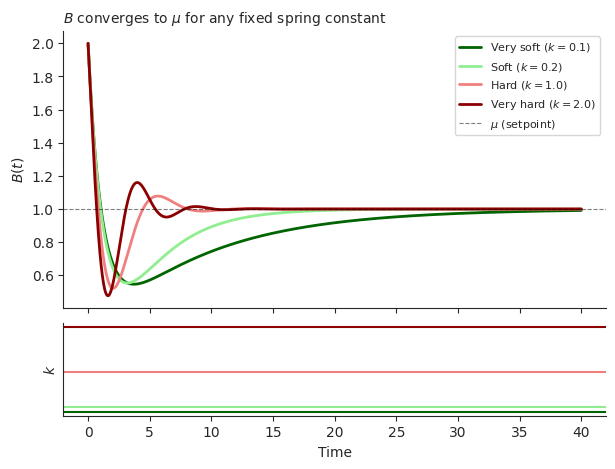

In [96]:
# Panel: Fixed spring constants — 4 variants converge to setpoint
# Use a longer time horizon so even the softest spring fully converges.
# T_springs is local and does NOT affect T or any other panel's data.
T_springs = 40.0
t_springs = np.linspace(0, T_springs, 4000)

p = PANEL_D
springs = [
    ('very_soft', p['alpha_very_soft'], 'darkgreen'),
    ('soft',      p['alpha_soft'],      'lightgreen'),
    ('hard',      p['alpha_hard'],      'lightcoral'),
    ('very_hard', p['alpha_very_hard'], 'darkred'),
]

# Store results for reuse in composite figure
data_springs = {'t': t_springs, 'curves': []}
for name, alpha, color in springs:
    sol = solve_ivp(
        lambda t_, y, a=alpha: minimal_rhs(y, a, p['beta1'], p['beta2']).tolist(),
        [0, T_springs], p['x0'], dense_output=True, max_step=0.1)
    k = alpha * p['beta1']
    data_springs['curves'].append((name, k, color, sol.sol(t_springs)[1]))

fig, (ax_B, ax_k) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

for name, k, color, B in data_springs['curves']:
    ax_B.plot(t_springs, B, lw=2, color=color,
              label=rf'{name.replace("_", " ").capitalize()} ($k={k}$)')
    ax_k.axhline(k, lw=1.5, color=color)

ax_B.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.5, label=r'$\mu$ (setpoint)')
ax_B.set_ylabel(r'$B(t)$')
ax_B.set_title(r'$B$ converges to $\mu$ for any fixed spring constant',
               fontsize=10, loc='left')
ax_B.legend(fontsize=8)
clean_ax(ax_B)
plt.setp(ax_B.get_xticklabels(), visible=False)

ax_k.set_ylabel(r'$k$')
ax_k.set_xlabel('Time')
ax_k.set_yticks([])
clean_ax(ax_k)

plt.tight_layout()
fig.savefig('figure2_panelD_springs.pdf', bbox_inches='tight')
plt.show()


**Panel E** — The Calcium signaling model is also equivalent to a damped harmonic oscillator.

The 3-variable Calcium model:

$$P = k_0(R_0 - Ca), \qquad \frac{dCa}{dt} = k_1 P + k_2 D - V_{cl}, \qquad \frac{dD}{dt} = k_3 P$$

reduces to a single second-order ODE directly in $Ca$:

$$\frac{d^2Ca}{dt^2} + k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0\, Ca = k_2 k_3 k_0\, R_0$$

with:

| Physical quantity | Parameter |
|---|---|
| Mass $m$ | $1$ |
| Damping $c$ | $k_1 k_0$ |
| **Spring constant $k$** | $k_2 k_3 k_0$ |
| Equilibrium $Ca_{\text{eq}}$ | $R_0$ |

See the full derivation in the SI.

/tmp/ipykernel_1406795/3660102158.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


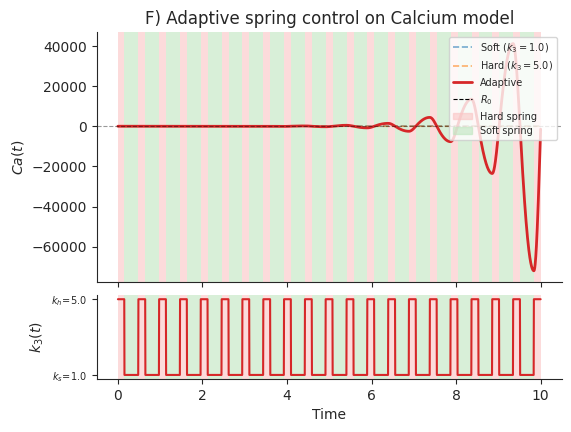

In [97]:
# Panel F: standalone plot — Ca(t) with k3(t) schedule below
dG = data_G
fig, (ax_Ca, ax_k) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

shade_spring(ax_Ca, dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])
shade_spring(ax_k,  dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])

ax_Ca.plot(dG['t_fixed'], dG['fixed']['soft'], lw=1.2, ls='--', alpha=0.6, color='C0',
           label=rf'Soft ($k_3={CALCIUM["k3_soft"]}$)')
ax_Ca.plot(dG['t_fixed'], dG['fixed']['hard'], lw=1.2, ls='--', alpha=0.6, color='C1',
           label=rf'Hard ($k_3={CALCIUM["k3_hard"]}$)')
ax_Ca.plot(dG['adaptive']['t'], dG['adaptive']['y'][:, 0], lw=2, color='C3', label='Adaptive')
ax_Ca.axhline(CALCIUM['R0'], color='black', ls='--', lw=0.8, alpha=0.4, label=r'$R_0$')
ax_Ca.set_ylabel('$Ca(t)$')
ax_Ca.set_title(r'F) Adaptive spring control on Calcium model')
ax_Ca.legend(handles=[
    plt.Line2D([0],[0], color='C0', ls='--', lw=1.2, alpha=0.6, label=rf'Soft ($k_3={CALCIUM["k3_soft"]}$)'),
    plt.Line2D([0],[0], color='C1', ls='--', lw=1.2, alpha=0.6, label=rf'Hard ($k_3={CALCIUM["k3_hard"]}$)'),
    plt.Line2D([0],[0], color='C3', lw=2, label='Adaptive'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$R_0$'),
    mpatches.Patch(color=HARD_COLOR, alpha=SHADE_ALPHA, label='Hard spring'),
    mpatches.Patch(color=SOFT_COLOR, alpha=SHADE_ALPHA, label='Soft spring'),
], fontsize=7, loc='upper right')
clean_ax(ax_Ca)
plt.setp(ax_Ca.get_xticklabels(), visible=False)

ax_k.plot(dG['adaptive']['t'], dG['adaptive']['k3'], lw=1.5, color='C3')
ax_k.set_ylabel(r'$k_3(t)$')
ax_k.set_xlabel('Time')
ax_k.set_yticks([CALCIUM['k3_soft'], CALCIUM['k3_hard']])
ax_k.set_yticklabels([rf"$k_s\!=\!{CALCIUM['k3_soft']}$", rf"$k_h\!=\!{CALCIUM['k3_hard']}$"], fontsize=7)
clean_ax(ax_k)

plt.tight_layout()
fig.savefig('figure2_panelF.pdf', bbox_inches='tight')
plt.show()


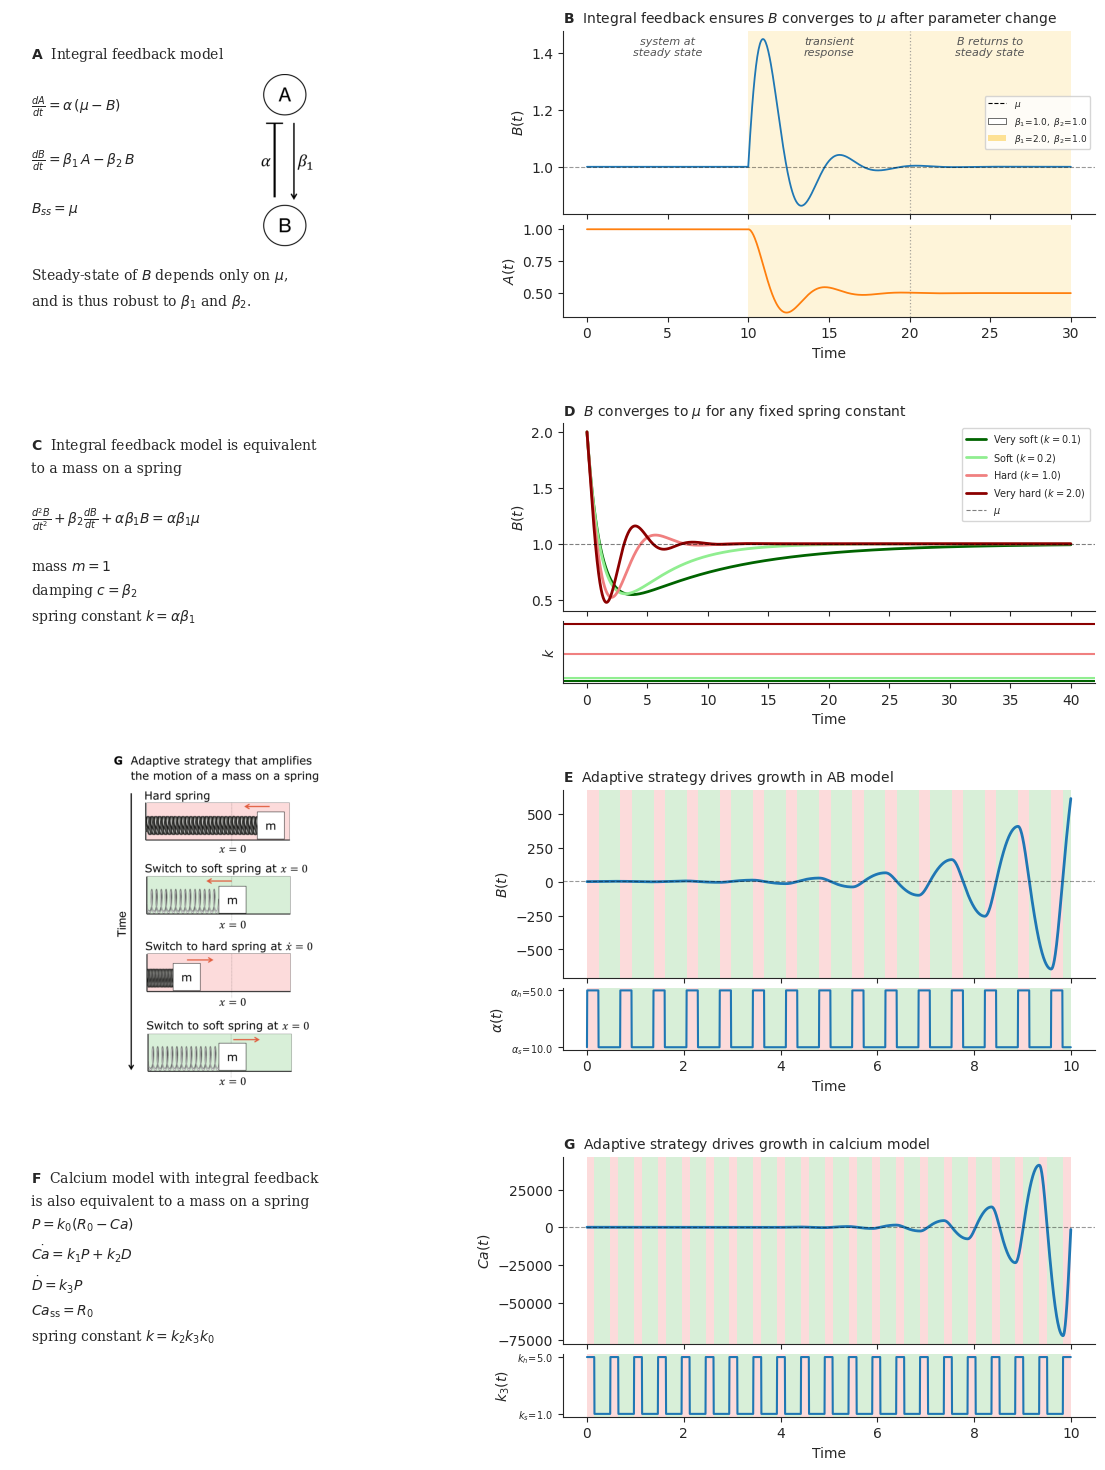

In [99]:
# ======================================================================
# COMPOSITE FIGURE  —  4×2 grid
#   Row 0: A (col 0) | B (col 1)
#   Row 1: C (col 0) | D fixed-springs + k schedule (col 1)
#   Row 2: G image   (col 0, enlarged) | E adaptive switching + alpha(t) (col 1)
#   Row 3: F calcium equations (col 0) | G calcium adaptive + k3(t) (col 1)
# ======================================================================
fig = plt.figure(figsize=(14, 18))

gs = gridspec.GridSpec(4, 2, figure=fig,
                       height_ratios=[1.1, 1.0, 1.0, 1.0],
                       width_ratios=[0.85, 1.1],
                       hspace=0.4, wspace=0.3)

# --- Panel A: equations + image inset (row 0, col 0) ---
ax_A = fig.add_subplot(gs[0, 0])
text_panel(ax_A, [
    r'$\mathbf{A}$  Integral feedback model',
    '', r'$\frac{dA}{dt} = \alpha\,(\mu - B)$',
    '', r'$\frac{dB}{dt} = \beta_1\, A - \beta_2\, B$',
    '', r'$B_{ss} = \mu$',
    '',
    '', r'Steady-state of $B$ depends only on $\mu$,',
    r'and is thus robust to $\beta_1$ and $\beta_2$.'
], fontsize=10)
ax_A_img = ax_A.inset_axes([0.0, 0.24, 1.5*0.9, 0.675*0.9])
ax_A_img.imshow(plt.imread('ab_model.png'))
ax_A_img.axis('off')

# --- Panel B: B(t) on top, A(t) below (row 0, col 1) ---
t_settled_B = 20.0
gs_B = gs[0, 1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.08)
ax_B  = fig.add_subplot(gs_B[0])
ax_BA = fig.add_subplot(gs_B[1], sharex=ax_B)

for ax in (ax_B, ax_BA):
    ax.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
    ax.axvline(t_settled_B, color='gray', ls=':', lw=0.9, alpha=0.7)

ax_B.plot(data_B['t'], data_B['B'], lw=1.3, color='C0')
ax_B.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4)
ax_B.set_ylabel('$B(t)$')
ax_B.set_title(r'$\mathbf{B}$  Integral feedback ensures $B$ converges to $\mu$ after parameter change',
               fontsize=10, loc='left')
trans_B = ax_B.get_xaxis_transform()
kw_B = dict(ha='center', va='top', fontsize=8, color='#555555',
            fontstyle='italic', transform=trans_B)
ax_B.text(data_B['t_switch'] / 2,                   0.97, 'system at\nsteady state', **kw_B)
ax_B.text((data_B['t_switch'] + t_settled_B) / 2,   0.97, 'transient\nresponse',     **kw_B)
ax_B.text((t_settled_B + data_B['t'].max()) / 2,    0.97, 'B returns to\nsteady state', **kw_B)
ax_B.legend(handles=[
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$\mu$'),
    mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.4,
                   label=rf'$\beta_1\!=\!{PANEL_B["beta1_base"]},\;\beta_2\!=\!{PANEL_B["beta2_base"]}$'),
    mpatches.Patch(facecolor='#fcba03', edgecolor='none', alpha=0.4,
                   label=rf'$\beta_1\!=\!{PANEL_B["beta1_pert"]},\;\beta_2\!=\!{PANEL_B["beta2_pert"]}$'),
], fontsize=6.5, loc='center right')
clean_ax(ax_B)
plt.setp(ax_B.get_xticklabels(), visible=False)

ax_BA.plot(data_B['t'], data_B['A'], lw=1.3, color='C1')
ax_BA.set_ylabel('$A(t)$')
ax_BA.set_xlabel('Time')
clean_ax(ax_BA)

# --- Panel C: spring equivalence text (row 1, col 0) ---
ax_C = fig.add_subplot(gs[1, 0])
text_panel(ax_C, [
    r'$\mathbf{C}$  Integral feedback model is equivalent',
    r'to a mass on a spring',
    '', r'$\frac{d^2B}{dt^2} + \beta_2\frac{dB}{dt} + \alpha\beta_1 B = \alpha\beta_1 \mu$',
    '', r'mass $m = 1$', r'damping $c = \beta_2$',
    r'spring constant $k = \alpha\beta_1$',
], fontsize=10)

# --- Panel D: fixed spring constants + k schedule (row 1, col 1) ---
gs_D = gs[1, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax_D  = fig.add_subplot(gs_D[0])
ax_Dk = fig.add_subplot(gs_D[1], sharex=ax_D)

for name, k, color, B in data_springs['curves']:
    ax_D.plot(data_springs['t'], B, lw=2, color=color,
              label=rf'{name.replace("_", " ").capitalize()} ($k={k}$)')
    ax_Dk.axhline(k, lw=1.5, color=color)

ax_D.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.5, label=r'$\mu$')
ax_D.set_ylabel('$B(t)$')
ax_D.set_title(r'$\mathbf{D}$  $B$ converges to $\mu$ for any fixed spring constant',
               fontsize=10, loc='left')
ax_D.legend(fontsize=7)
clean_ax(ax_D)
plt.setp(ax_D.get_xticklabels(), visible=False)

ax_Dk.set_ylabel(r'$k$')
ax_Dk.set_xlabel('Time')
ax_Dk.set_yticks([])
clean_ax(ax_Dk)

# --- Panel G image (row 2, col 0) — enlarged beyond grid cell ---
G_SCALE = 1.3  # increase to make the image larger (overlaps neighboring cells)
ax_G = fig.add_subplot(gs[2, 0])
pos = ax_G.get_position()
ax_G.set_position([
    pos.x0 - pos.width  * (G_SCALE - 1) / 2,
    pos.y0 - pos.height * (G_SCALE - 1) / 2,
    pos.width  * G_SCALE,
    pos.height * G_SCALE,
])
img_G = plt.imread('figure2_panelG.png')
ax_G.imshow(img_G)
ax_G.axis('off')
ax_G.set_zorder(0)  # keep behind other panels

# --- Panel E: adaptive switching + alpha(t) schedule (row 2, col 1) ---
gs_E = gs[2, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax_E  = fig.add_subplot(gs_E[0])
ax_Ea = fig.add_subplot(gs_E[1], sharex=ax_E)

shade_spring(ax_E,  data_E['t'], data_E['alpha'], PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])
shade_spring(ax_Ea, data_E['t'], data_E['alpha'], PANEL_E['alpha_hard'], PANEL_E['alpha_soft'])

ax_E.plot(data_E['t'], data_E['y'][:, 1], lw=2, color='C0')
ax_E.axhline(mu, color='black', ls='--', lw=0.8, alpha=0.4)
ax_E.set_ylabel('$B(t)$')
ax_E.set_title(r'$\mathbf{E}$  Adaptive strategy drives growth in AB model', fontsize=10, loc='left')
clean_ax(ax_E)
plt.setp(ax_E.get_xticklabels(), visible=False)

ax_Ea.plot(data_E['t'], data_E['alpha'], lw=1.5, color='C0')
ax_Ea.set_ylabel(r'$\alpha(t)$')
ax_Ea.set_xlabel('Time')
ax_Ea.set_yticks([PANEL_E['alpha_soft'], PANEL_E['alpha_hard']])
ax_Ea.set_yticklabels([rf"$\alpha_s\!=\!{PANEL_E['alpha_soft']}$",
                       rf"$\alpha_h\!=\!{PANEL_E['alpha_hard']}$"], fontsize=7)
clean_ax(ax_Ea)

# --- Panel F: calcium equations (row 3, col 0) ---
ax_F = fig.add_subplot(gs[3, 0])
text_panel(ax_F, [
    r'$\mathbf{F}$  Calcium model with integral feedback',
    r'is also equivalent to a mass on a spring',
    r'$P = k_0(R_0 - Ca)$',
    r'$\dot{Ca} = k_1 P + k_2 D \quad$',
    r'$\dot{D} = k_3 P$',
    r'$Ca_{\rm ss} = R_0$',
    r'spring constant $k = k_2 k_3 k_0$',
], fontsize=10)

# --- Panel G: calcium adaptive + k3(t) schedule (row 3, col 1) ---
dG = data_G
gs_Gc = gs[3, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax_Gc = fig.add_subplot(gs_Gc[0])
ax_Gk = fig.add_subplot(gs_Gc[1], sharex=ax_Gc)

shade_spring(ax_Gc, dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])
shade_spring(ax_Gk, dG['adaptive']['t'], dG['adaptive']['k3'],
             CALCIUM['k3_hard'], CALCIUM['k3_soft'])

ax_Gc.plot(dG['adaptive']['t'], dG['adaptive']['y'][:, 0], lw=2, color='C0')
ax_Gc.axhline(CALCIUM['R0'], color='black', ls='--', lw=0.8, alpha=0.4)
ax_Gc.set_ylabel('$Ca(t)$')
ax_Gc.set_title(r'$\mathbf{G}$  Adaptive strategy drives growth in calcium model', fontsize=10, loc='left')
clean_ax(ax_Gc)
plt.setp(ax_Gc.get_xticklabels(), visible=False)

ax_Gk.plot(dG['adaptive']['t'], dG['adaptive']['k3'], lw=1.5, color='C0')
ax_Gk.set_ylabel(r'$k_3(t)$')
ax_Gk.set_xlabel('Time')
ax_Gk.set_yticks([CALCIUM['k3_soft'], CALCIUM['k3_hard']])
ax_Gk.set_yticklabels([rf"$k_s\!=\!{CALCIUM['k3_soft']}$",
                       rf"$k_h\!=\!{CALCIUM['k3_hard']}$"], fontsize=7)
clean_ax(ax_Gk)

fig.savefig('figure2_composite_fixed.pdf', bbox_inches='tight')
plt.show()


# Supplementary:

### SI: Derivation — Integral Feedback as a Damped Mass-Spring System

**Goal:** Transform the coupled first-order ODE system into a single second-order ODE equivalent to a damped harmonic oscillator.

**Given System:**

$$\frac{dA}{dt} = \alpha(\mu - B) \tag{1}$$

$$\frac{dB}{dt} = \beta_1 A - \beta_2 B \tag{2}$$

**Step 1:** Differentiate Eq. 2 with respect to $t$:

$$\frac{d^2B}{dt^2} = \beta_1 \frac{dA}{dt} - \beta_2 \frac{dB}{dt}$$

**Step 2:** Substitute $\frac{dA}{dt}$ from Eq. 1:

$$\frac{d^2B}{dt^2} = \beta_1 \alpha(\mu - B) - \beta_2 \frac{dB}{dt}$$

**Step 3:** Rearrange into standard second-order form:

$$\frac{d^2B}{dt^2} + \beta_2 \frac{dB}{dt} + \alpha\beta_1 B = \alpha\beta_1\mu$$

**Step 4:** Map to the damped mass-spring equation $m\ddot{x} + c\dot{x} + kx = F_{\text{ext}}$:

| Physical quantity | Our system |
|---|---|
| Mass ($m$) | $1$ |
| Damping coefficient ($c$) | $\beta_2$ |
| Spring constant ($k$) | $\alpha\beta_1$ |
| External force ($F_{\text{ext}}$) | $\alpha\beta_1\mu$ |

**Step 5:** Define displacement from equilibrium $x(t) = B(t) - \mu$. Since $\mu$ is constant, $\dot{x} = \dot{B}$ and $\ddot{x} = \ddot{B}$. Substituting $B = x + \mu$:

$$\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1(x + \mu) = \alpha\beta_1\mu$$

$$\boxed{\ddot{x} + \beta_2\,\dot{x} + \alpha\beta_1\,x = 0}$$

This confirms the system behaves as a damped spring with spring constant $k = \alpha\beta_1$, oscillating around the equilibrium $B_{\text{eq}} = \mu$.

### SI: Derivation — Calcium Model as a Damped Mass-Spring System

**Goal:** Reduce the 3-variable Calcium system ($P$, $Ca$, $D$) into a single second-order ODE in $Ca$.

**Given System:**

$$P = k_0(R_0 - Ca) \tag{1}$$

$$\frac{dCa}{dt} = k_1 P + k_2 D - V_{cl} \tag{2}$$

$$\frac{dD}{dt} = k_3 P \tag{3}$$

**Step 1:** Substitute $P$ from Eq. 1 into Eqs. 2 and 3:

$$\frac{dCa}{dt} = k_1 k_0(R_0 - Ca) + k_2 D - V_{cl}$$

$$\frac{dD}{dt} = k_3 k_0(R_0 - Ca)$$

**Step 2:** Differentiate the $\frac{dCa}{dt}$ equation with respect to $t$ (all $k$'s, $R_0$, $V_{cl}$ constant):

$$\frac{d^2Ca}{dt^2} = -k_1 k_0 \frac{dCa}{dt} + k_2 \frac{dD}{dt}$$

**Step 3:** Substitute $\frac{dD}{dt}$ from Step 1:

$$\frac{d^2Ca}{dt^2} = -k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0(R_0 - Ca)$$

**Step 4:** Rearrange into standard second-order form:

$$\frac{d^2Ca}{dt^2} + k_1 k_0 \frac{dCa}{dt} + k_2 k_3 k_0\, Ca = k_2 k_3 k_0\, R_0$$

**Step 5:** Map to the damped mass-spring equation $m\ddot{x} + c\dot{x} + kx = F_{\text{ext}}$:

| Physical quantity | Our system |
|---|---|
| Mass ($m$) | $1$ |
| Damping coefficient ($c$) | $k_1 k_0$ |
| Spring constant ($k$) | $k_2 k_3 k_0$ |
| External force ($F_{\text{ext}}$) | $k_2 k_3 k_0\, R_0$ |

**Step 6:** At steady state, $\frac{dD}{dt} = 0$ requires $Ca = R_0$. Define $x(t) = Ca(t) - R_0$:

$$\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0(x + R_0) = k_2 k_3 k_0\, R_0$$

$$\boxed{\ddot{x} + k_1 k_0\,\dot{x} + k_2 k_3 k_0\,x = 0}$$

This confirms the Calcium dynamics behave as a damped spring with spring constant $k = k_2 k_3 k_0$, oscillating around $Ca_{\text{eq}} = R_0$.